In [1]:
!pip install -q gdown
import gdown
import zipfile
import os

# 1. Download
file_id = '1zaznBnFm3PnHy_9WQBhgjF_HLwb7L9Zs'
zip_file = 'EyeDiseaseDataset.zip'
gdown.download(id=file_id, output=zip_file, quiet=False, fuzzy=True)

# 2. Extract
extract_path = './dataset'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

Downloading...
From (original): https://drive.google.com/uc?id=1zaznBnFm3PnHy_9WQBhgjF_HLwb7L9Zs
From (redirected): https://drive.google.com/uc?id=1zaznBnFm3PnHy_9WQBhgjF_HLwb7L9Zs&confirm=t&uuid=4517bcac-d4fd-40f3-bf69-0dafd8322a32
To: /kaggle/working/EyeDiseaseDataset.zip
100%|██████████| 4.08G/4.08G [00:43<00:00, 94.1MB/s]


['Tasks_and_Classes.md', 'metadata.csv', 'splits', 'catalog', 'images']


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50V2  # Updated to ResNet50V2 for improved performance
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix




In [34]:
import cv2

In [3]:
def merge_data(image_dir , data_path):
  df = pd.read_csv(data_path)

  df['full_path'] = df['filename'].apply(lambda x: os.path.join(image_dir, x))

  df['exists'] = df['full_path'].apply(os.path.exists)
  df = df[df['exists']].reset_index(drop=True)

  return df




In [4]:
image_dir = './dataset/images'
metadata_path = './dataset/metadata.csv'

df=merge_data(image_dir , metadata_path)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11839 entries, 0 to 11838
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   filename        11839 non-null  object
 1   dataset         11839 non-null  object
 2   unified_label   11839 non-null  object
 3   original_label  11839 non-null  object
 4   full_path       11839 non-null  object
 5   exists          11839 non-null  bool  
dtypes: bool(1), object(5)
memory usage: 474.2+ KB


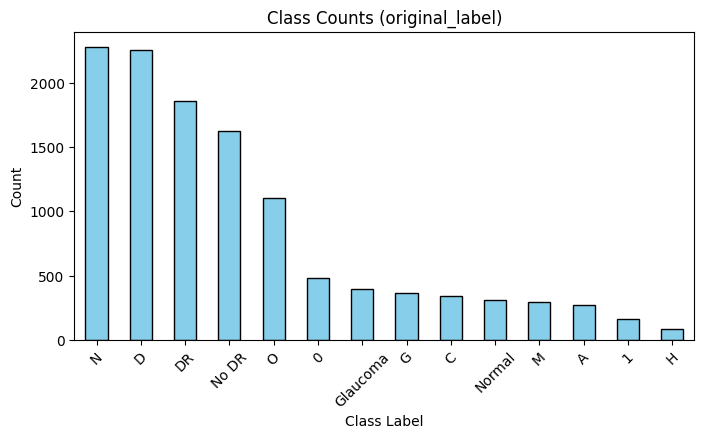

/tmp/ipykernel_58/2249100551.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='original_label', palette='viridis')


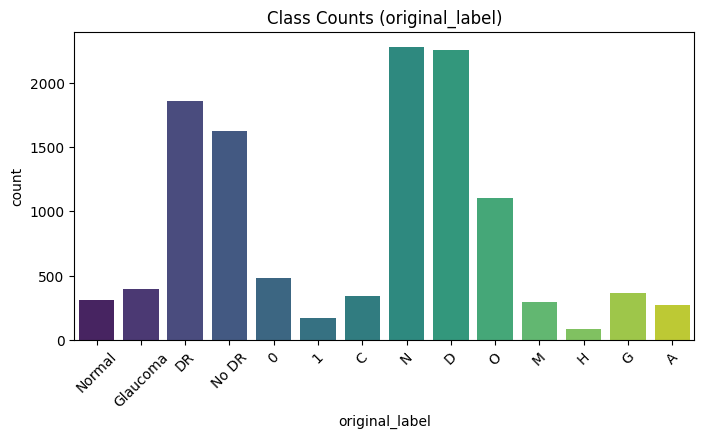

In [7]:

plt.figure(figsize=(8, 4))
df['original_label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Counts (original_label)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#  Seaborn
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='original_label', palette='viridis')
plt.title('Class Counts (original_label)')
plt.xticks(rotation=45)
plt.show()

In [8]:

unique_classes = df['original_label'].unique().tolist()
print("Unique classes found:", unique_classes)



Unique classes found: ['Normal', 'Glaucoma', 'DR', 'No DR', '0', '1', 'C', 'N', 'D', 'O', 'M', 'H', 'G', 'A']


unified

In [ ]:
unique_classes = df['unified_label'].unique().tolist()
print("Unique classes found:", unique_classes)

Unique classes found: ['Normal', 'Glaucoma', 'Diabetic Retinopathy', 'Cataract', 'Others', 'Myopia', 'Hypertension', 'AMD']


In [9]:

class_counts = df['original_label'].value_counts(dropna=False)
print("\nClass breakdown:")
print(class_counts)


Class breakdown:
original_label
N           2280
D           2256
DR          1857
No DR       1627
O           1102
0            482
Glaucoma     396
G            366
C            340
Normal       309
M            294
A            274
1            168
H             88
Name: count, dtype: int64


 variations for same class

In [6]:
label_map = {

    '0': 'Normal',
    'N': 'Normal',
    'NO DR': 'Normal',
    'No DR':'Normal',
    'NORMAL': 'Normal',
    'Normal': 'Normal',

    '1': 'Diabetic Retinopathy',
    'D': 'Diabetic Retinopathy',
    'DR': 'Diabetic Retinopathy',
    'Diabetic Retinopathy': 'Diabetic Retinopathy',

    'G': 'Glaucoma',
    'Glaucoma' :'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Others'
}

def clean_label(df_):
  df_['clean_label'] = df_['original_label'].astype(str).str.strip().map(label_map)
#then we encode
  return df_

df=clean_label(df)
unmapped_labels = df[df['clean_label'].isna()]['original_label'].unique()
print("Remaining unmapped classes:", unmapped_labels)
print("\nFinal Unified Counts:")
print(df['clean_label'].value_counts())


Remaining unmapped classes: []

Final Unified Counts:
clean_label
Normal                  4698
Diabetic Retinopathy    4281
Others                  1102
Glaucoma                 762
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


/tmp/ipykernel_58/2981412159.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='clean_label', palette='viridis')


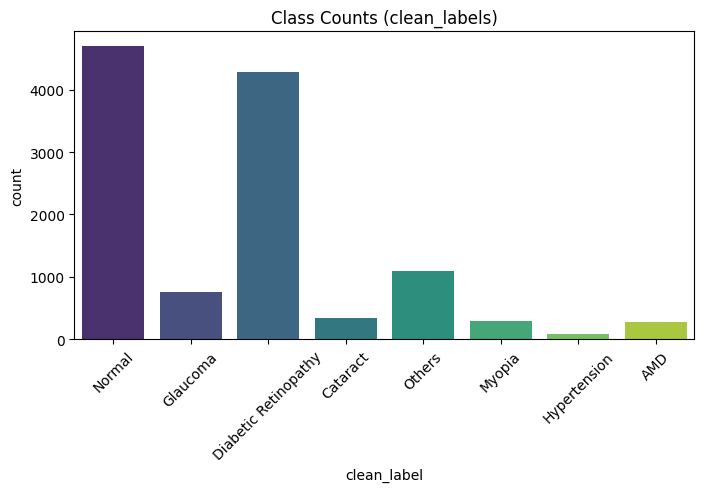

In [ ]:

plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='clean_label', palette='viridis')
plt.title('Class Counts (clean_labels)')
plt.xticks(rotation=45)
plt.show()

In [11]:


def show_samples_per_class(df, samples_per_class=2, random_state=42):

    unique_classes = df['clean_label'].unique()

    fig, axes = plt.subplots(
        nrows=len(unique_classes),
        ncols=samples_per_class,
        figsize=(samples_per_class * 2.5, len(unique_classes) * 2.5),
        squeeze=False
    )

    for row_idx, class_name in enumerate(unique_classes):

        class_df = df[df['clean_label'] == class_name]

        sampled_rows = class_df.sample(
            n=min(samples_per_class, len(class_df)),
            random_state=random_state
        )

        # Hide all subplot positions first
        for col_idx in range(samples_per_class):
            axes[row_idx, col_idx].axis('off')

        # Show available images
        for col_idx, (_, row) in enumerate(sampled_rows.iterrows()):

            img = Image.open(row['full_path'])

            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].set_title(
                class_name,
                fontsize=10
            )
            axes[row_idx, col_idx].axis('off')

    plt.tight_layout()
    plt.show()


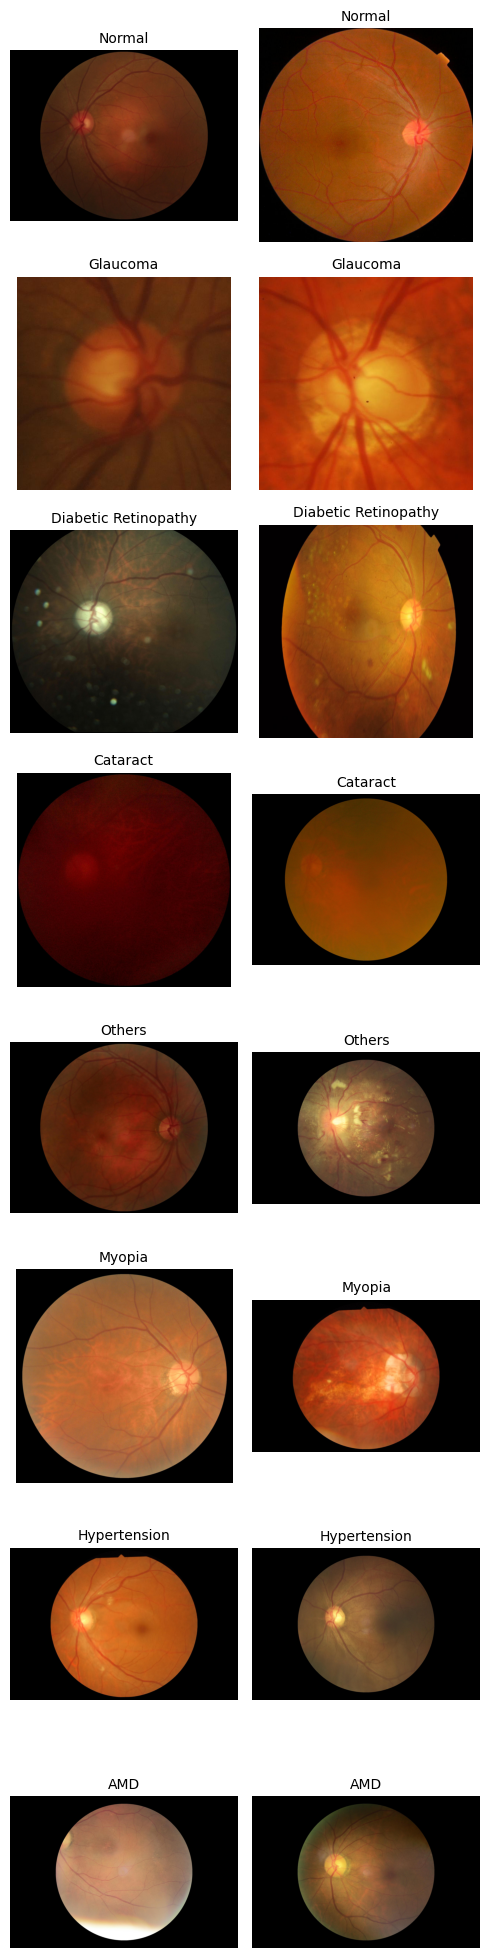

In [12]:
show_samples_per_class(df, samples_per_class=2, random_state=42)

In [7]:


def encoding (df_):
  label_encoder = LabelEncoder()

  df_['encoded_label'] = label_encoder.fit_transform(df_['clean_label'])

  class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
  #df=df.drop(columns=['unified_label','original_label','exists'],)
  return class_mapping ,df_

class_mapping ,df =encoding(df)
print("Class Index Mapping:", class_mapping)

df.head()

Class Index Mapping: {'AMD': np.int64(0), 'Cataract': np.int64(1), 'Diabetic Retinopathy': np.int64(2), 'Glaucoma': np.int64(3), 'Hypertension': np.int64(4), 'Myopia': np.int64(5), 'Normal': np.int64(6), 'Others': np.int64(7)}


,filename,dataset,unified_label,original_label,full_path,exists,clean_label,encoded_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im001_ACRIMA.jpg,True,Normal,6
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im002_ACRIMA.jpg,True,Normal,6
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im003_ACRIMA.jpg,True,Normal,6
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im004_ACRIMA.jpg,True,Normal,6
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im005_ACRIMA.jpg,True,Normal,6


#validation_data

In [ ]:



val_csv_path = './dataset/splits/val.csv'
val_df_meta = pd.read_csv(val_csv_path)
# set??
val_filenames = set(val_df_meta['filename'].tolist())

df['split'] = df['filename'].apply(lambda x: 'val' if x in val_filenames else 'train')


train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
val_df.to_csv('./dataset/splits/val_df.csv', index=False)
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

Train shape: (10642, 9)
Val shape: (1197, 9)


In [ ]:
val_data=merge_data('./dataset/images' ,'./dataset/splits/val_df.csv' )
print(f"Matched {len(val_data)} images with metadata.")

val_data=clean_label(val_data)
unmapped_labels = val_data[val_data['clean_label'].isna()]['original_label'].unique()
print("Remaining unmapped classes:", unmapped_labels)
print("\nFinal Unified Counts:")
print(val_data['clean_label'].value_counts())



Matched 1197 images with metadata.
Remaining unmapped classes: []

Final Unified Counts:
clean_label
Normal                  467
Diabetic Retinopathy    443
Others                  110
Glaucoma                 76
Cataract                 34
Myopia                   30
AMD                      28
Hypertension              9
Name: count, dtype: int64


In [ ]:
class_mapping, val_data= encoding(val_data)
val_data.head()

,filename,dataset,unified_label,original_label,full_path,exists,clean_label,encoded_label,split
0,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im005_ACRIMA.jpg,True,Normal,6,val
1,ACRIMA_Im029_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im029_ACRIMA.jpg,True,Normal,6,val
2,ACRIMA_Im035_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im035_ACRIMA.jpg,True,Normal,6,val
3,ACRIMA_Im057_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im057_ACRIMA.jpg,True,Normal,6,val
4,ACRIMA_Im073_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im073_ACRIMA.jpg,True,Normal,6,val


In [ ]:
image=Image.open(df['full_path'][0])
print(image)

In [ ]:
x=1197/11839
print(x)

For CNN trianing

In [8]:

NUM_CLASSES = df['clean_label'].nunique()

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['clean_label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (9471, 8)
Test shape: (2368, 8)


In [9]:
class_counts = train_df['clean_label'].value_counts()
threshold = class_counts.median()
minority_classes = class_counts[class_counts < threshold].index.tolist()
majority_classes = class_counts[class_counts >= threshold].index.tolist()

print(f"Median class count: {threshold}")
print("Minority classes (aggressive aug + oversampling):", minority_classes)
print("Majority classes (mild/no aug, untouched counts):", majority_classes)

Median class count: 441.0
Minority classes (aggressive aug + oversampling): ['Cataract', 'Myopia', 'AMD', 'Hypertension']
Majority classes (mild/no aug, untouched counts): ['Normal', 'Diabetic Retinopathy', 'Others', 'Glaucoma']


Post-oversampling train counts:
 clean_label
Normal                  3758
Diabetic Retinopathy    3425
Others                   882
Glaucoma                 610
Hypertension             441
Myopia                   441
AMD                      441
Cataract                 441
Name: count, dtype: int64


/tmp/ipykernel_58/1794266980.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df_aug, x='clean_label', palette='viridis',


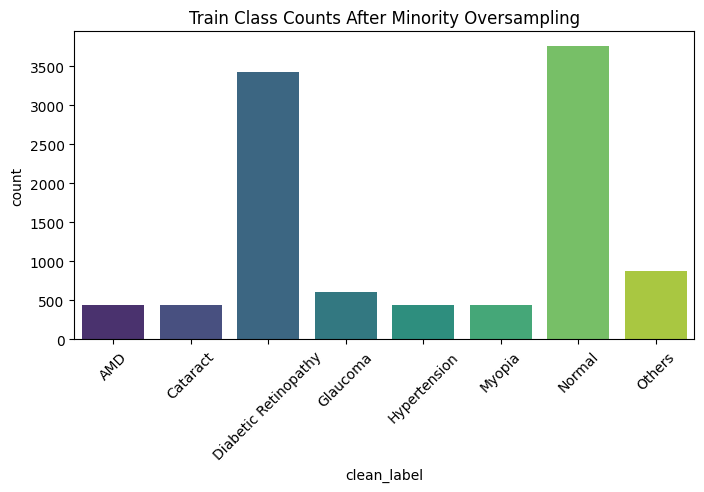

In [10]:
def oversample_minority(df_, minority_classes, label_col='clean_label', target_count=None):
    if target_count is None:
        target_count = int(df_[label_col].value_counts().median())

    parts = []
    for cls, cls_df in df_.groupby(label_col):
        if cls in minority_classes and len(cls_df) < target_count:
            cls_df = resample(cls_df, replace=True, n_samples=target_count, random_state=42)
        parts.append(cls_df)

    out = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
    out['is_minority'] = out[label_col].isin(minority_classes)
    return out

target_count = int(threshold)  # bring minority classes up to the median majority-ish level
train_df_aug = oversample_minority(train_df, minority_classes, target_count=target_count)

print("Post-oversampling train counts:\n", train_df_aug['clean_label'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=train_df_aug, x='clean_label', palette='viridis',
              order=sorted(df['clean_label'].unique()))
plt.title('Train Class Counts After Minority Oversampling')
plt.xticks(rotation=45)
plt.show()

In [21]:
test_df.shape

(2368, 8)

In [12]:
train_df_aug.shape

(10439, 9)

In [13]:
IMG_SIZE = 300  
BATCH_SIZE = 16  

def crop_and_resize(img_path):
    path = img_path.numpy().decode('utf-8')
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 8
    if np.any(mask):
        rows, cols = np.where(mask)
        img = img[rows.min():rows.max(), cols.min():cols.max()]

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32)  # raw 0-255 scale; EfficientNet rescales internally

def load_image(path, label, is_minority):
    img = tf.py_function(func=crop_and_resize, inp=[path], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label, is_minority

aggressive_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.30),
    layers.RandomTranslation(0.20, 0.20),
    layers.RandomContrast(0.35),
    layers.RandomBrightness(0.35),
], name="aggressive_augmentation")

mild_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="mild_augmentation")

def augment(img, label, is_minority):
    img = tf.expand_dims(img, 0)
    img = tf.cond(
        is_minority,
        lambda: aggressive_aug(img, training=True),
        lambda: mild_aug(img, training=True)
    )
    img = tf.squeeze(img, 0)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset(dataframe, training=True, batch_size=BATCH_SIZE):
    paths = dataframe['full_path'].values
    labels = dataframe['encoded_label'].values
    is_minority_flags = dataframe.get('is_minority', pd.Series([False] * len(dataframe))).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, is_minority_flags))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda img, label, is_min: (img, tf.one_hot(label, NUM_CLASSES)),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df_aug, training=True)
test_ds = make_dataset(test_df, training=False)



I0000 00:00:1790094642.825830      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790094642.832110      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


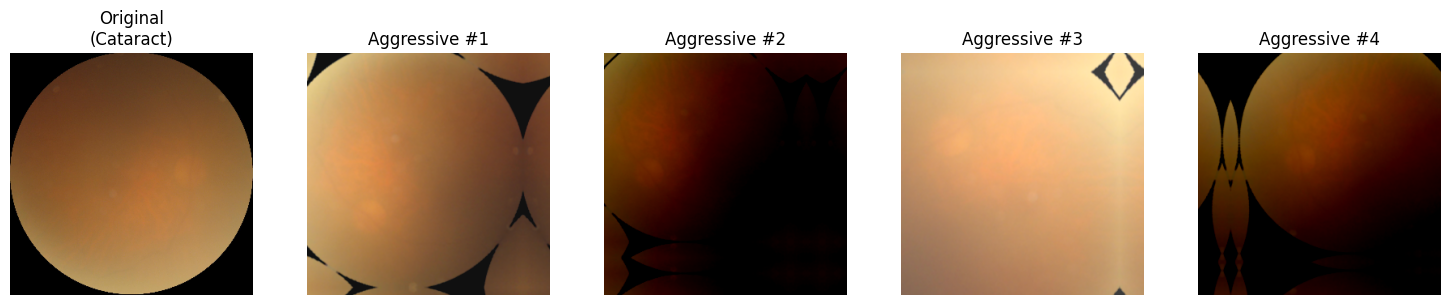

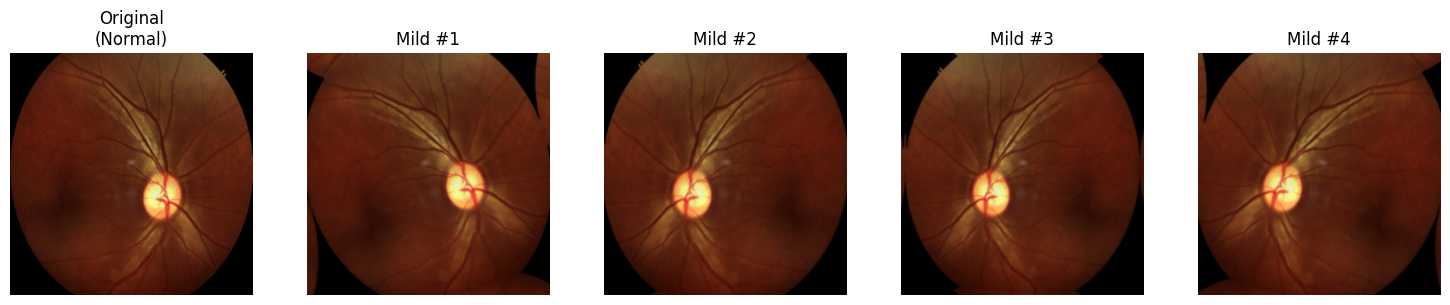

In [29]:
import cv2
def preview_augmentation(dataframe, class_name, n=4):
    sample_path = dataframe[dataframe['clean_label'] == class_name]['full_path'].iloc[0]
    img = crop_and_resize(tf.constant(sample_path))
    is_min = class_name in minority_classes
    aug_fn = aggressive_aug if is_min else mild_aug

    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3))
    axes[0].imshow(img.astype('uint8'))
    axes[0].set_title(f"Original\n({class_name})")
    axes[0].axis('off')

    for i in range(n):
        aug_img = aug_fn(tf.expand_dims(img, 0), training=True)[0].numpy()
        aug_img = np.clip(aug_img, 0, 255).astype('uint8')
        axes[i + 1].imshow(aug_img)
        axes[i + 1].set_title(f"{'Aggressive' if is_min else 'Mild'} #{i+1}")
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

# Example: one minority class, one majority class
preview_augmentation(train_df, minority_classes[0], n=4)
preview_augmentation(train_df, majority_classes[0], n=4)

In [14]:
def plot_training_history( hist):
  hist= hist.history if hasattr(hist, 'history') else None
  acc = hist.get('accuracy') or hist.history.get('acc', [])
  val_acc = (hist.get('val_accuracy') or hist.get('val_acc', []))
  loss = hist.get('loss', [])
  val_loss = hist.get('val_loss', [])

  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(acc, label='Train Accuracy')
  plt.plot(val_acc, label='Val Accuracy')
  plt.title('Accuracy Across Epochs')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(loss, label='Train Loss')
  plt.plot(val_loss, label='Val Loss')
  plt.title('Loss Across Epochs')
  plt.legend()
  plt.show()

In [ ]:
from sklearn.utils import resample
import pandas as pd

def balance_dataframe(df, label_col='clean_label', target_samples_per_class=1065):
    balanced_dfs = []
    for cls in df[label_col].unique():
        cls_df = df[df[label_col] == cls]
        resampled_cls = resample(
            cls_df,
            replace=True,
            n_samples=target_samples_per_class,
            random_state=42
        )
        balanced_dfs.append(resampled_cls)

    return pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Apply balancing to training DataFrame
balanced_train_df = balance_dataframe(train_df, target_samples_per_class=1065)
print("Balanced Train Counts:\n", balanced_train_df['clean_label'].value_counts())

Balanced Train Counts:
 clean_label
Hypertension            1065
Glaucoma                1065
Diabetic Retinopathy    1065
Normal                  1065
Others                  1065
Cataract                1065
AMD                     1065
Myopia                  1065
Name: count, dtype: int64


In [ ]:
import cv2
import numpy as np

def preprocess_fundus(img):
    #uint8 for OpenCV
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 8

    #
    if np.any(mask):
        row_indices, col_indices = np.where(mask)
        img = img[
            np.min(row_indices):np.max(row_indices),
            np.min(col_indices):np.max(col_indices)
        ]


    img = cv2.resize(img, (224, 224))


    return img.astype(np.float32)





In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_fundus,
    rotation_range=30,
    horizontal_flip=True,
                 #vertical_flip=True,   Mirror vertically (valid for eye images)
    zoom_range=0.15,                  # >>> Slight zoom in/out
    width_shift_range=0.1,            # >> Small horizontal translations
    height_shift_range=0.1,           #>> Small vertical translations
    shear_range=0.1,                  # >>>> Geometric distortion
    brightness_range=[0.8, 1.2],
    fill_mode='constant',

)


train_generator = train_datagen.flow_from_dataframe(
    dataframe=balanced_train_df,
    x_col='full_path',
    y_col='clean_label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Validation & Test Generator
val_test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_fundus
)


val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col='clean_label',
    target_size= (224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Test
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col='clean_label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False            )

In [ ]:

def build_scratch_functional_cnn(input_shape=(224, 224, 3), num_classes=8):

    inputs = layers.Input(shape=input_shape, name="input_image")

    x = layers.Rescaling(1./255, name="rescaling")(inputs)


    x = layers.Conv2D(64, (3, 3), padding='same', name="conv1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation('relu', name="relu1")(x)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x) # Output: (112, 112, 64)


    x = layers.Conv2D(128, (3, 3), padding='same', name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation('relu', name="relu2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x) # Output: (56, 56, 128)

    #B3
    x = layers.Conv2D(256, (3, 3), padding='same', name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Activation('relu', name="relu3")(x)
    x = layers.MaxPooling2D((2, 2), name="pool3")(x) # Output: (28, 28, 256)

    # >> Classification Head <<
    # GlobalAveragePooling2D replaces heavy Flatten layers to prevent parameter explosion
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    x = layers.Dense(128, name="dense1")(x)
    x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.Activation('relu', name="relu_dense")(x)
    x = layers.Dropout(0.2, name="dropout2")(x)

    # Softmax for Multi-class
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Scratch_Functional_CNN")
    return model

# Instantiate and check model summary
num_classes = len(train_df['clean_label'].unique())
model = build_scratch_functional_cnn(input_shape=(224, 224, 3), num_classes=num_classes)

model.summary()

I0000 00:00:1789995971.532129      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789995971.538170      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Scratch_Functional_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,048 (1.55 MB)

 Trainable params: 405,896 (1.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=train_df['clean_label'].unique(),
    y=train_df['clean_label']
)
class_weight_dict = dict(zip(train_df['clean_label'].unique(), class_weights))
print("Class Weights Dictionary:", class_weight_dict)

Class Weights Dictionary: {'Normal': np.float64(0.3150279403938265), 'Diabetic Retinopathy': np.float64(0.34565693430656935), 'Others': np.float64(1.3422619047619047), 'Myopia': np.float64(5.037765957446808), 'Cataract': np.float64(4.352481617647059), 'AMD': np.float64(5.405821917808219), 'Glaucoma': np.float64(1.9407786885245901), 'Hypertension': np.float64(16.9125)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    # Stop training >> val loss patience=4
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    # Reduce lrate when val loss plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-5),
    # Save the best model checkpoint
    ModelCheckpoint('best_scratch_cnn.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history = model.fit(
   x=train_generator ,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/20


2026-09-21 13:14:32.037907: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 13:14:32.214384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/266 ━━━━━━━━━━━━━━━━━━━━ 1:21:19 18s/step - accuracy: 0.1250 - auc: 0.4208 - loss: 2.7037

I0000 00:00:1789996478.853362     168 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.2242 - auc: 0.6314 - loss: 2.0897
Epoch 1: val_loss improved from None to 2.59471, saving model to best_scratch_cnn.h5


...


Epoch 5: finished saving model to best_scratch_cnn.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.3601 - auc: 0.7546 - loss: 1.7293 - val_accuracy: 0.3617 - val_auc: 0.7661 - val_loss: 1.6945 - learning_rate: 0.0010
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.3960 - auc: 0.7846 - loss: 1.6407
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_loss did not improve from 1.69448
266/266 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.3986 - auc: 0.7887 - loss: 1.6286 - val_accuracy: 0.3225 - val_auc: 0.7361 - val_loss: 1.7849 - learning_rate: 0.0010
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.4234 - auc: 0.8024 - loss: 1.5844
Epoch 8: val_loss improved from 1.69448 to 1.59750, saving model to best_scratch_cnn.h5



Epoch 8: finished saving model to best_scratch_cnn.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.4295 - auc: 0.8089 - loss: 1.5621 - val_accuracy: 0.3634 - val_auc: 0.7968 - val_loss: 1.5975 - learning_rate: 5.0000e-04
Epoch 9/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.4429 - auc: 0.8153 - loss: 1.5325
Epoch 9: val_loss did not improve from 1.59750
266/266 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4448 - auc: 0.8187 - loss: 1.5233 - val_accuracy: 0.3175 - val_auc: 0.7658 - val_loss: 1.7004 - learning_rate: 5.0000e-04
Epoch 10/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.4525 - auc: 0.8209 - loss: 1.5172
Epoch 10: val_loss improved from 1.59750 to 1.59657, saving model to best_scratch_cnn.h5



Epoch 10: finished saving model to best_scratch_cnn.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4512 - auc: 0.8230 - loss: 1.5100 - val_accuracy: 0.3676 - val_auc: 0.7904 - val_loss: 1.5966 - learning_rate: 5.0000e-04
Epoch 11/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.4687 - auc: 0.8296 - loss: 1.4861
Epoch 11: val_loss did not improve from 1.59657
266/266 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.4697 - auc: 0.8320 - loss: 1.4732 - val_accuracy: 0.2698 - val_auc: 0.7055 - val_loss: 1.9412 - learning_rate: 5.0000e-04
Epoch 12/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.4713 - auc: 0.8346 - loss: 1.4640
Epoch 12: val_loss improved from 1.59657 to 1.52508, saving model to best_scratch_cnn.h5



Epoch 12: finished saving model to best_scratch_cnn.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.4729 - auc: 0.8332 - loss: 1.4673 - val_accuracy: 0.3818 - val_auc: 0.8153 - val_loss: 1.5251 - learning_rate: 5.0000e-04
Epoch 13/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.4795 - auc: 0.8368 - loss: 1.4527
Epoch 13: val_loss improved from 1.52508 to 1.33571, saving model to best_scratch_cnn.h5



Epoch 13: finished saving model to best_scratch_cnn.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4738 - auc: 0.8353 - loss: 1.4588 - val_accuracy: 0.4979 - val_auc: 0.8667 - val_loss: 1.3357 - learning_rate: 5.0000e-04
Epoch 14/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.4710 - auc: 0.8383 - loss: 1.4430
Epoch 14: val_loss did not improve from 1.33571
266/266 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.4760 - auc: 0.8391 - loss: 1.4419 - val_accuracy: 0.3517 - val_auc: 0.7954 - val_loss: 1.6602 - learning_rate: 5.0000e-04
Epoch 15/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.4907 - auc: 0.8477 - loss: 1.4109
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 15: val_loss did not improve from 1.33571
266/266 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4824 - auc: 0.8456 - loss: 1.4190 - val_accuracy: 0.4119 - val_auc: 0.8239 - val_loss: 1.4782 - learning_rate: 5.0000e-04
Epoch 16/20
266/266 ━━━━━━━━━━

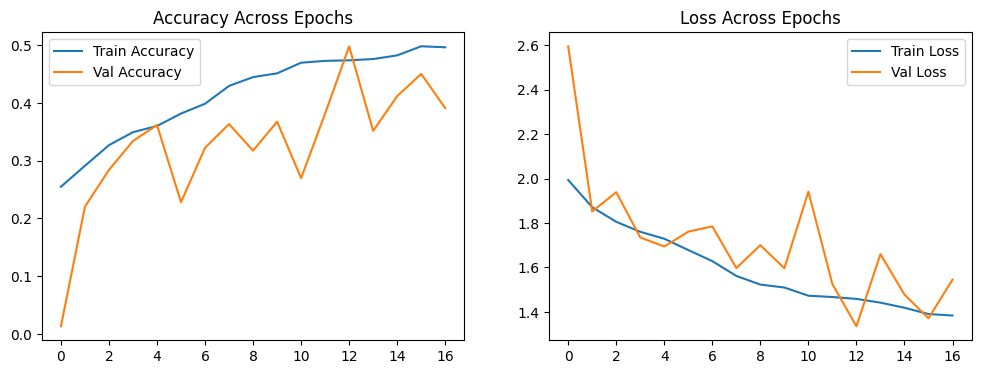

In [ ]:
from IPython.display import FileLink

model.save('final_eye_disease_cnn_model.h5')
FileLink('final_eye_disease_cnn_model.h5')

plot_training_history(history)




In [ ]:
FileLink('final_eye_disease_cnn_model.h5')


/kaggle/working/final_eye_disease_cnn_model.h5

0.9258 discrimination capability between classes across variable confidence thresholds.,
accuracy: 0.6241

In [39]:

def evaluate_and_report(model, generator):
 y_pred_probs = model.predict(generator, steps=len(generator))
 y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure indices match class labels
 y_true = generator.classes
 class_labels = list(generator.class_indices.keys())
 print("\n--- Per-Class Classification Report ---")
 print(classification_report(y_true, y_pred, target_names=class_labels))



 cm = confusion_matrix(y_true, y_pred)
 plt.figure(figsize=(8, 6))
 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
 plt.title('Test Set Confusion Matrix')
 plt.xlabel('Predicted Label')
 plt.ylabel('True Label')
 plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 50s 664ms/step

--- Per-Class Classification Report ---
                      precision    recall  f1-score   support

                 AMD       0.05      0.13      0.08        55
            Cataract       0.40      0.40      0.40        68
Diabetic Retinopathy       0.48      0.64      0.55       856
            Glaucoma       0.41      0.59      0.48       152
        Hypertension       0.02      0.06      0.03        18
              Myopia       0.70      0.27      0.39        59
              Normal       0.60      0.46      0.52       940
              Others       0.12      0.01      0.02       220

            accuracy                           0.47      2368
           macro avg       0.35      0.32      0.31      2368
        weighted avg       0.48      0.47      0.46      2368



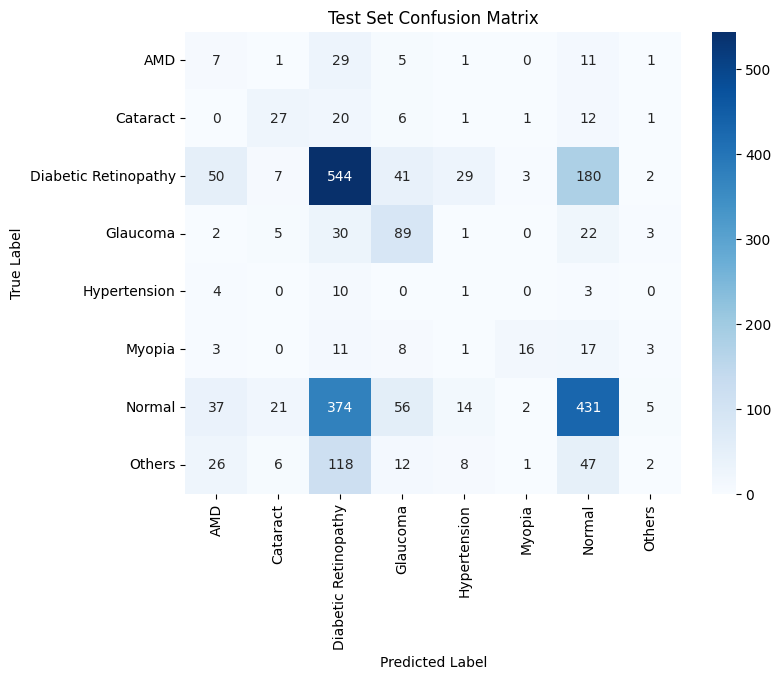

In [ ]:
evaluate_and_report(model,test_generator)

#cnn

AMD ,HYPERTENSION ,OTHERS (CLASSES BALANCING ), black boundries ,

In [ ]:
from sklearn.utils import resample
import pandas as pd

def balance_dataframe(df, label_col='clean_label', target_samples_per_class=1064):
    balanced_dfs = []
    for cls in df[label_col].unique():
        cls_df = df[df[label_col] == cls]
        resampled_cls = resample(
            cls_df,
            replace=True,
            n_samples=target_samples_per_class,
            random_state=42
        )
        balanced_dfs.append(resampled_cls)

    return pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Apply balancing to training DataFrame
balanced_train_df = balance_dataframe(train_df, target_samples_per_class=1064)
print("Balanced Train Counts:\n", balanced_train_df['clean_label'].value_counts())

Balanced Train Counts:
 clean_label
Cataract                1064
Diabetic Retinopathy    1064
Hypertension            1064
Glaucoma                1064
AMD                     1064
Myopia                  1064
Normal                  1064
Others                  1064
Name: count, dtype: int64


In [ ]:
import cv2
import numpy as np

def preprocess_fundus(img):
    #uint8 for OpenCV
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 8

    #
    if np.any(mask):
        row_indices, col_indices = np.where(mask)
        img = img[
            np.min(row_indices):np.max(row_indices),
            np.min(col_indices):np.max(col_indices)
        ]


    img = cv2.resize(img, (224, 224))


    return img.astype(np.float32)





In [ ]:
import cv2
import numpy as np

def preprocess_Resfundus(img):
    # Ensure image is in uint8 [0, 255] range
    img = img.astype(np.uint8)

    # Extract Green channel (contains highest contrast for retinal vessels)
    g_channel = img[:, :, 1]

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_g = clahe.apply(g_channel)

    # Recombine to 3-channel image
    enhanced_img = cv2.merge([img[:, :, 0], enhanced_g, img[:, :, 2]])

    return enhanced_img.astype(np.float32)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_fundus,
    rotation_range=30,
    horizontal_flip=True,
                 #vertical_flip=True,   Mirror vertically (valid for eye images)
    zoom_range=0.15,                  # >>> Slight zoom in/out
    width_shift_range=0.1,            # >> Small horizontal translations
    height_shift_range=0.1,           #>> Small vertical translations
    shear_range=0.1,                  # >>>> Geometric distortion
    brightness_range=[0.8, 1.2],
    fill_mode='constant',

)


train_generator = train_datagen.flow_from_dataframe(
    dataframe=balanced_train_df,
    x_col='full_path',
    y_col='clean_label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Validation & Test Generator
val_test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_fundus
)


val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col='clean_label',
    target_size= (224, 224 ),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Test
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col='clean_label',
    target_size= (224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False            )

Found 8520 validated image filenames belonging to 8 classes.
Found 2145 validated image filenames belonging to 8 classes.
Found 2368 validated image filenames belonging to 8 classes.


***Transfer learning ,, Model***

In [ ]:
def plot_training_history( hist):
  hist= hist.history if hasattr(hist, 'history') else None
  acc = hist.get('accuracy') or hist.history.get('acc', [])
  val_acc = (hist.get('val_accuracy') or hist.get('val_acc', []))
  loss = hist.get('loss', [])
  val_loss = hist.get('val_loss', [])

  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(acc, label='Train Accuracy')
  plt.plot(val_acc, label='Val Accuracy')
  plt.title('Accuracy Across Epochs')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(loss, label='Train Loss')
  plt.plot(val_loss, label='Val Loss')
  plt.title('Loss Across Epochs')
  plt.legend()
  plt.show()

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(train_df['clean_label'])
weights = compute_class_weight('balanced', classes=classes, y=train_df['clean_label'])


# [AMD, Cataract, Diabetic Retinopathy, Glaucoma, Hypertension, Myopia, Normal, Others]
custom_multipliers = np.array([3.5, 1.5, 1.0, 2.5, 3.5, 2.0, 1.0, 2.2])
adjusted_weights = weights * custom_multipliers

class_weight_dict = dict(enumerate(adjusted_weights))

Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3796 - auc: 0.7125 - loss: 2.3205

266/266 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.4248 - auc: 0.7515 - loss: 1.7416 - val_accuracy: 0.1069 - val_auc: 0.5478 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4773 - auc: 0.7935 - loss: 1.0899

266/266 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 0.4952 - auc: 0.8074 - loss: 0.9472 - val_accuracy: 0.1654 - val_auc: 0.5689 - val_loss: 0.7261 - learning_rate: 0.0010
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5361 - auc: 0.8333 - loss: 0.7397
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


266/266 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.5315 - auc: 0.8310 - loss: 0.7212 - val_accuracy: 0.2531 - val_auc: 0.6374 - val_loss: 0.6404 - learning_rate: 0.0010
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.5525 - auc: 0.8461 - loss: 0.5990 - val_accuracy: 0.2899 - val_auc: 0.6292 - val_loss: 0.6492 - learning_rate: 5.0000e-04
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5739 - auc: 0.8577 - loss: 0.5294

266/266 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.5717 - auc: 0.8568 - loss: 0.5386 - val_accuracy: 0.3141 - val_auc: 0.6547 - val_loss: 0.5989 - learning_rate: 5.0000e-04
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.5832 - auc: 0.8633 - loss: 0.5006 - val_accuracy: 0.3033 - val_auc: 0.6467 - val_loss: 0.6183 - learning_rate: 5.0000e-04
Epoch 7/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5934 - auc: 0.8691 - loss: 0.4925

266/266 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.5992 - auc: 0.8726 - loss: 0.4655 - val_accuracy: 0.3183 - val_auc: 0.6638 - val_loss: 0.5890 - learning_rate: 5.0000e-04
Epoch 8/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6034 - auc: 0.8783 - loss: 0.4501

266/266 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.6123 - auc: 0.8807 - loss: 0.4376 - val_accuracy: 0.3333 - val_auc: 0.6797 - val_loss: 0.5640 - learning_rate: 5.0000e-04
Epoch 9/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.6089 - auc: 0.8805 - loss: 0.4165 - val_accuracy: 0.3099 - val_auc: 0.6774 - val_loss: 0.5584 - learning_rate: 5.0000e-04
Epoch 10/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6239 - auc: 0.8898 - loss: 0.4208

266/266 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.6201 - auc: 0.8872 - loss: 0.4184 - val_accuracy: 0.3158 - val_auc: 0.6853 - val_loss: 0.5501 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 10.


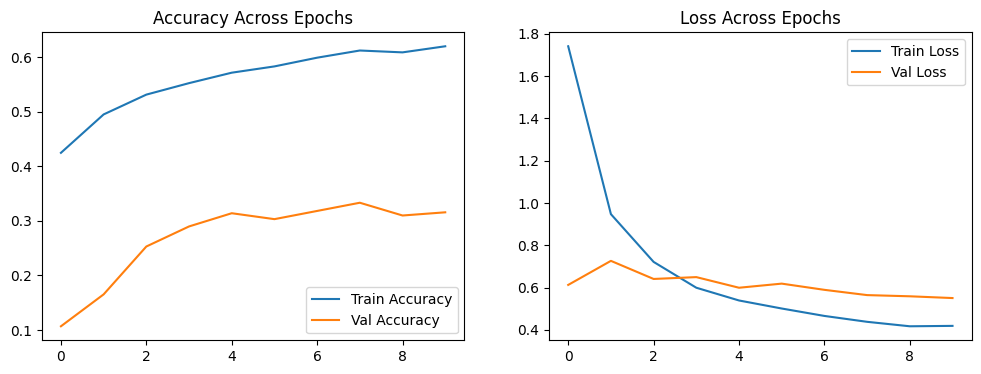

In [ ]:

num_classes = len(train_df['clean_label'].unique())

inputs = layers.Input(shape=( 300, 300 , 3), name="input_image")

# Preprocessing layer specifically calibrated for ResNet50V2 inputs [-1, 1]
x_preprocessed = tf.keras.applications.resnet_v2.preprocess_input(inputs)

base_model = ResNet50V2(include_top=False, weights='imagenet', input_tensor=x_preprocessed)
base_model.trainable = False  # Freeze base layers initially

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = Model(inputs=inputs, outputs=outputs, name="EyeDisease_ResNet_TL")

#<<<<<<<<Training Top Head >>>>>

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint('best_eye_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

history_TL_phase1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks_phase1 ,
    class_weight=class_weight_dict
)
model.save('final_eye_disease_modelTL_Phase1.h5')


plot_training_history(history_TL_phase1)



In [ ]:
from IPython.display import FileLink
FileLink('final_eye_disease_modelTL_Phase1.h5')

/kaggle/working/final_eye_disease_modelTL_Phase1.h5

Epoch 1/6
  2/267 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.1719 - auc: 0.5214 - loss: 10.8000   

I0000 00:00:1790071358.397959     192 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.3857 - auc: 0.7186 - loss: 3.6245

267/267 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.4322 - auc: 0.7540 - loss: 2.2823 - val_accuracy: 0.1156 - val_auc: 0.5247 - val_loss: 0.6885 - learning_rate: 0.0010
Epoch 2/6
267/267 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.5093 - auc: 0.8106 - loss: 1.0554 - val_accuracy: 0.1459 - val_auc: 0.5109 - val_loss: 0.7756 - learning_rate: 0.0010
Epoch 3/6
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.5174 - auc: 0.8235 - loss: 0.9264
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


267/267 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.5319 - auc: 0.8275 - loss: 0.8941 - val_accuracy: 0.1734 - val_auc: 0.5403 - val_loss: 0.7458 - learning_rate: 0.0010
Epoch 4/6
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.5443 - auc: 0.8355 - loss: 0.7796

267/267 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.5583 - auc: 0.8414 - loss: 0.7297 - val_accuracy: 0.2009 - val_auc: 0.5748 - val_loss: 0.6849 - learning_rate: 5.0000e-04
Epoch 5/6
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.5625 - auc: 0.8481 - loss: 0.6498

267/267 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.5718 - auc: 0.8529 - loss: 0.6564 - val_accuracy: 0.2084 - val_auc: 0.5916 - val_loss: 0.6540 - learning_rate: 5.0000e-04
Epoch 6/6
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.5771 - auc: 0.8572 - loss: 0.6074

267/267 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.5822 - auc: 0.8604 - loss: 0.5863 - val_accuracy: 0.2247 - val_auc: 0.6207 - val_loss: 0.6024 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 6.


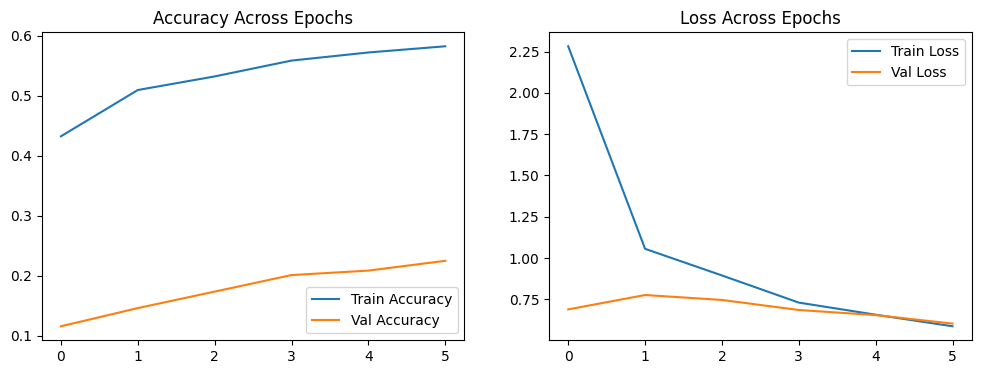

In [ ]:

num_classes = len(train_df['clean_label'].unique())

inputs = layers.Input(shape=( 224, 224 , 3), name="input_image")

# Preprocessing layer specifically calibrated for ResNet50V2 inputs [-1, 1]
x_preprocessed = tf.keras.applications.resnet_v2.preprocess_input(inputs)

base_model = ResNet50V2(include_top=False, weights='imagenet', input_tensor=x_preprocessed)
base_model.trainable = False  # Freeze base layers initially

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = Model(inputs=inputs, outputs=outputs, name="EyeDisease_ResNet_TL")

#<<<<<<<<Training Top Head >>>>>

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint('best_eye_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

history_TL_phase1 = model.fit(
    train_generator,
    epochs=6,
    validation_data=val_generator,
    callbacks=callbacks_phase1 ,
    class_weight=class_weight_dict
)
model.save('final_eye_disease_modelTL_Phase1.h5')


plot_training_history(history_TL_phase1)



In [ ]:


# Freeze all except the top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Freeze Batch Normalization lys
for layer in base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False




model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalFocalCrossentropy () ,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_eye_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

history_TL_phase2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks_phase2 ,
    class_weight=class_weight_dict
)
model.save('final_eye_disease_modelTL_Phase2.h5')

plot_training_history(history_TL_phase2)
FileLink('final_eye_disease_modelTL_Phase2.h5')

Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.6096 - auc: 0.8748 - loss: 0.5188

267/267 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.6045 - auc: 0.8749 - loss: 0.5138 - val_accuracy: 0.2485 - val_auc: 0.6350 - val_loss: 0.5867 - learning_rate: 1.0000e-04
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.6040 - auc: 0.8744 - loss: 0.5107

267/267 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.6086 - auc: 0.8772 - loss: 0.5113 - val_accuracy: 0.2508 - val_auc: 0.6380 - val_loss: 0.5774 - learning_rate: 1.0000e-04
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.6161 - auc: 0.8789 - loss: 0.4965 - val_accuracy: 0.2485 - val_auc: 0.6345 - val_loss: 0.5805 - learning_rate: 1.0000e-04
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.6313 - auc: 0.8834 - loss: 0.4432

267/267 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.6205 - auc: 0.8812 - loss: 0.4592 - val_accuracy: 0.2559 - val_auc: 0.6449 - val_loss: 0.5547 - learning_rate: 1.0000e-04
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.6132 - auc: 0.8811 - loss: 0.4487

267/267 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.6134 - auc: 0.8818 - loss: 0.4728 - val_accuracy: 0.2508 - val_auc: 0.6456 - val_loss: 0.5648 - learning_rate: 1.0000e-04
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.6202 - auc: 0.8837 - loss: 0.4519

...

267/267 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.6273 - auc: 0.8868 - loss: 0.4441 - val_accuracy: 0.2583 - val_auc: 0.6554 - val_loss: 0.5491 - learning_rate: 1.0000e-04
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.6317 - auc: 0.8899 - loss: 0.4441

267/267 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.6297 - auc: 0.8896 - loss: 0.4299 - val_accuracy: 0.2797 - val_auc: 0.6725 - val_loss: 0.5190 - learning_rate: 1.0000e-04
Epoch 9/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.6315 - auc: 0.8918 - loss: 0.4233 - val_accuracy: 0.2811 - val_auc: 0.6723 - val_loss: 0.5217 - learning_rate: 1.0000e-04
Epoch 10/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.6399 - auc: 0.8950 - loss: 0.4118 - val_accuracy: 0.2797 - val_auc: 0.6706 - val_loss: 0.5267 - learning_rate: 1.0000e-04
Epoch 11/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.6468 - auc: 0.8947 - loss: 0.3773
Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
267/267 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.6415 - auc: 0.8947 - loss: 0.3960 - val_accuracy: 0.2830 - val_auc: 0.6717 - val_loss: 0.5275 - learning_rate: 1.0000e-04
Epoch 12/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.6466 - auc: 0.89

267/267 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.6464 - auc: 0.8957 - loss: 0.3898 - val_accuracy: 0.2988 - val_auc: 0.6798 - val_loss: 0.5124 - learning_rate: 5.0000e-05
Epoch 13/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.6504 - auc: 0.8968 - loss: 0.3900

267/267 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.6453 - auc: 0.8979 - loss: 0.3850 - val_accuracy: 0.3072 - val_auc: 0.6851 - val_loss: 0.5073 - learning_rate: 5.0000e-05
Epoch 14/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.6358 - auc: 0.8952 - loss: 0.4139

267/267 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.6452 - auc: 0.8976 - loss: 0.3920 - val_accuracy: 0.3100 - val_auc: 0.6867 - val_loss: 0.5003 - learning_rate: 5.0000e-05
Epoch 15/20
 13/267 ━━━━━━━━━━━━━━━━━━━━ 3:48 900ms/step - accuracy: 0.5904 - auc: 0.8661 - loss: 0.3503

#EfficientNetB5 transfer-learning model

In [15]:
from tensorflow.keras.applications import EfficientNetB5
num_classes=8
input_shape=(IMG_SIZE, IMG_SIZE, 3)
inputs = layers.Input(shape=input_shape, name="input_image")

    # EfficientNet applies its own internal rescaling/normalization -> feed raw 0-255 pixels
base_model = EfficientNetB5(include_top=False, weights='imagenet', input_tensor=inputs)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = Model(inputs=inputs, outputs=outputs, name="EyeDisease_EfficientNetB5_TL")

model.summary()

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EyeDisease_EfficientNetB5_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │      1,152 │ block1a_se_excit

 Total params: 29,048,319 (110.81 MB)

 Trainable params: 530,696 (2.02 MB)

 Non-trainable params: 28,517,623 (108.79 MB)

In [32]:
classes = np.unique(train_df_aug['encoded_label'])
weights = compute_class_weight('balanced', classes=classes, y=train_df_aug['encoded_label'])

class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weight dict :", class_weight_dict)


Class weight dict : {0: 2.9589002267573696, 1: 2.9589002267573696, 2: 0.380985401459854, 3: 2.1391393442622952, 4: 2.9589002267573696, 5: 2.9589002267573696, 6: 0.3472259180415114, 7: 1.4794501133786848}


Epoch 1/10


2026-09-22 16:43:21.701853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:43:21.865222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:43:23.332825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:43:23.476176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:43:23.742218: E external/local_xla/xla/stream_

652/653 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.4255 - auc: 0.8151 - loss: 0.4464

2026-09-22 16:49:46.297307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:49:46.442013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:49:47.844287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:49:47.981333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 16:49:48.222362: E external/local_xla/xla/stream_

653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.4255 - auc: 0.8152 - loss: 0.4462

653/653 ━━━━━━━━━━━━━━━━━━━━ 530s 709ms/step - accuracy: 0.4636 - auc: 0.8528 - loss: 0.3449 - val_accuracy: 0.4616 - val_auc: 0.8521 - val_loss: 0.3926 - learning_rate: 0.0010
Epoch 2/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.5222 - auc: 0.9016 - loss: 0.1957

653/653 ━━━━━━━━━━━━━━━━━━━━ 413s 631ms/step - accuracy: 0.5147 - auc: 0.9033 - loss: 0.1815 - val_accuracy: 0.4717 - val_auc: 0.8698 - val_loss: 0.3372 - learning_rate: 0.0010
Epoch 3/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 412s 630ms/step - accuracy: 0.5252 - auc: 0.9134 - loss: 0.1506 - val_accuracy: 0.4611 - val_auc: 0.8584 - val_loss: 0.3961 - learning_rate: 0.0010
Epoch 4/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.5210 - auc: 0.9139 - loss: 0.1397
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
653/653 ━━━━━━━━━━━━━━━━━━━━ 409s 626ms/step - accuracy: 0.5246 - auc: 0.9139 - loss: 0.1444 - val_accuracy: 0.4383 - val_auc: 0.8508 - val_loss: 0.3912 - learning_rate: 0.0010
Epoch 5/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 442s 626ms/step - accuracy: 0.5484 - auc: 0.9232 - loss: 0.1271 - val_accuracy: 0.4780 - val_auc: 0.8658 - val_loss: 0.3825 - learning_rate: 5.0000e-04
Epoch 6/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.5593 - auc: 0.9277 -

653/653 ━━━━━━━━━━━━━━━━━━━━ 406s 622ms/step - accuracy: 0.5553 - auc: 0.9273 - loss: 0.1174 - val_accuracy: 0.5312 - val_auc: 0.8784 - val_loss: 0.3541 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.


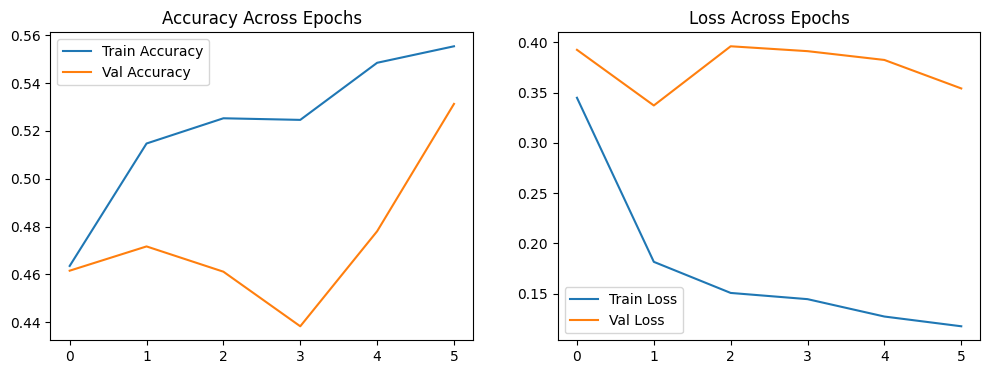

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
ModelCheckpoint('best_eye_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_phase1 = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1
)

model.save('final_eye_disease_effnb5_phase1.h5')
plot_training_history(history_phase1)

Epoch 1/20


2026-09-22 17:37:51.385891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 17:37:51.575465: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


652/653 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.5568 - auc: 0.9218 - loss: 0.1357

2026-09-22 17:44:14.147376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 17:44:14.336916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.5568 - auc: 0.9218 - loss: 0.1357

653/653 ━━━━━━━━━━━━━━━━━━━━ 517s 703ms/step - accuracy: 0.5551 - auc: 0.9221 - loss: 0.1370 - val_accuracy: 0.4700 - val_auc: 0.8663 - val_loss: 0.3433 - learning_rate: 1.0000e-05
Epoch 2/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.5493 - auc: 0.9236 - loss: 0.1314

653/653 ━━━━━━━━━━━━━━━━━━━━ 426s 652ms/step - accuracy: 0.5582 - auc: 0.9247 - loss: 0.1280 - val_accuracy: 0.4713 - val_auc: 0.8698 - val_loss: 0.3344 - learning_rate: 1.0000e-05
Epoch 3/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 420s 643ms/step - accuracy: 0.5601 - auc: 0.9272 - loss: 0.1192 - val_accuracy: 0.4641 - val_auc: 0.8681 - val_loss: 0.3557 - learning_rate: 1.0000e-05
Epoch 4/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.5598 - auc: 0.9271 - loss: 0.1213

653/653 ━━━━━━━━━━━━━━━━━━━━ 443s 645ms/step - accuracy: 0.5619 - auc: 0.9275 - loss: 0.1205 - val_accuracy: 0.4835 - val_auc: 0.8758 - val_loss: 0.3436 - learning_rate: 1.0000e-05
Epoch 5/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 419s 641ms/step - accuracy: 0.5683 - auc: 0.9304 - loss: 0.1144 - val_accuracy: 0.4835 - val_auc: 0.8750 - val_loss: 0.3000 - learning_rate: 1.0000e-05
Epoch 6/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 419s 641ms/step - accuracy: 0.5766 - auc: 0.9340 - loss: 0.1057 - val_accuracy: 0.4772 - val_auc: 0.8734 - val_loss: 0.3408 - learning_rate: 1.0000e-05
Epoch 7/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.5728 - auc: 0.9345 - loss: 0.1043

653/653 ━━━━━━━━━━━━━━━━━━━━ 427s 653ms/step - accuracy: 0.5708 - auc: 0.9339 - loss: 0.1064 - val_accuracy: 0.4916 - val_auc: 0.8782 - val_loss: 0.3192 - learning_rate: 1.0000e-05
Epoch 8/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5834 - auc: 0.9375 - loss: 0.1024
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
653/653 ━━━━━━━━━━━━━━━━━━━━ 420s 643ms/step - accuracy: 0.5843 - auc: 0.9368 - loss: 0.1020 - val_accuracy: 0.4797 - val_auc: 0.8756 - val_loss: 0.3204 - learning_rate: 1.0000e-05
Epoch 9/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 418s 639ms/step - accuracy: 0.5832 - auc: 0.9372 - loss: 0.1052 - val_accuracy: 0.4747 - val_auc: 0.8749 - val_loss: 0.3309 - learning_rate: 5.0000e-06
Epoch 10/20
653/653 ━━━━━━━━━━━━━━━━━━━━ 418s 640ms/step - accuracy: 0.5846 - auc: 0.9385 - loss: 0.1024 - val_accuracy: 0.4827 - val_auc: 0.8777 - val_loss: 0.3061 - learning_rate: 5.0000e-06
Epoch 10: early stopping
Restoring model weights from the end of the best e

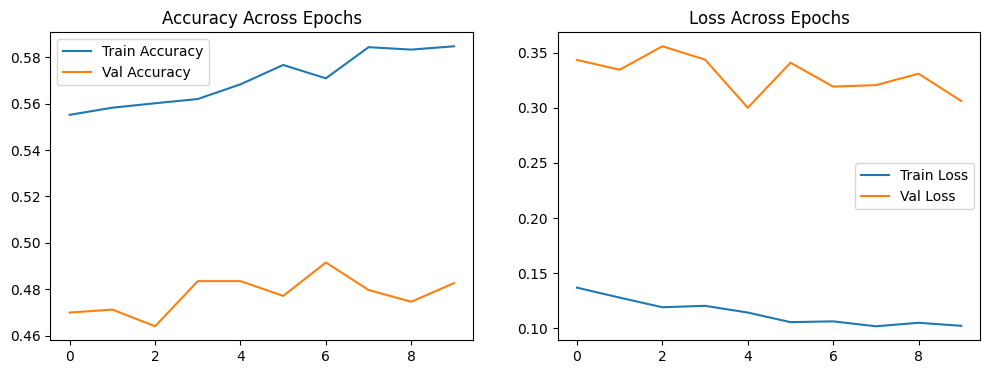

In [36]:
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 40
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False


for layer in base_model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_eye_effnb5_phase2.h5', monitor='val_auc', mode='max', save_best_only=True)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_phase2 = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)

model.save('final_eye_disease_effnb5_phase2.h5')
plot_training_history(history_phase2)

148/148 ━━━━━━━━━━━━━━━━━━━━ 66s 443ms/step

--- Per-Class Classification Report ---
                      precision    recall  f1-score   support

                 AMD       0.00      0.00      0.00        55
            Cataract       0.50      0.01      0.03        68
Diabetic Retinopathy       0.85      0.53      0.65       856
            Glaucoma       0.31      0.87      0.45       152
        Hypertension       0.00      0.00      0.00        18
              Myopia       0.80      0.07      0.12        59
              Normal       0.86      0.40      0.55       940
              Others       0.18      0.80      0.30       220

            accuracy                           0.48      2368
           macro avg       0.44      0.34      0.26      2368
        weighted avg       0.72      0.48      0.51      2368



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


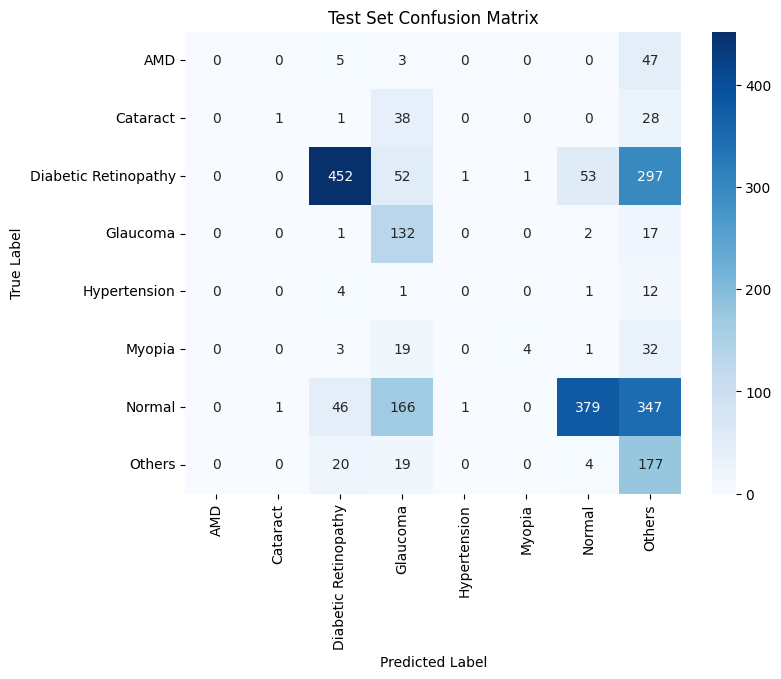

In [41]:
def evaluate_and_report_tfdata(model, dataset, df_ref, class_mapping):
    y_pred_probs = model.predict(dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = df_ref['encoded_label'].values

    inv_class_mapping = {v: k for k, v in class_mapping.items()}
    class_labels = [inv_class_mapping[i] for i in sorted(inv_class_mapping)]

    print("\n--- Per-Class Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Test Set Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

evaluate_and_report_tfdata(model, test_ds, test_df, class_mapping)

In [ ]:
from IPython.display import FileLink

FileLink('final_eye_disease_modelTL_Phase1.h5')
FileLink('final_eye_disease_modelTL_Phase2.h5')


In [ ]:
model.save('final_eye_disease_modelTL_Phase2.h5')
FileLink('final_eye_disease_modelTL_Phase2.h5')